In [2]:
import pandas as pd 

In [3]:
df = pd.read_excel(r'F:\GenAI&AgeAI\Notes\Dec\Dec19 - Pandas\data.xlsx')

In [4]:
df

,CountryName,CountryCode,BirthRate,InternetUsers,IncomeGroup
0,Aruba,ABW,10.244,78.9,High income
1,Afghanistan,AFG,35.253,5.9,Low income
2,Angola,AGO,45.985,19.1,Upper middle income
3,Albania,ALB,12.877,57.2,Upper middle income
4,United Arab Emirates,ARE,11.044,88.0,High income
...,...,...,...,...,...
190,"Yemen, Rep.",YEM,32.947,20.0,Lower middle income
191,South Africa,ZAF,20.850,46.5,Upper middle income
192,"Congo, Dem. Rep.",COD,42.394,2.2,Low income
193,Zambia,ZMB,40.471,15.4,Lower middle income


# Split Data

In [5]:
df.head(2)

,CountryName,CountryCode,BirthRate,InternetUsers,IncomeGroup
0,Aruba,ABW,10.244,78.9,High income
1,Afghanistan,AFG,35.253,5.9,Low income


In [8]:
df_num = df[['BirthRate','InternetUsers']]
df_num

,BirthRate,InternetUsers
0,10.244,78.9
1,35.253,5.9
2,45.985,19.1
3,12.877,57.2
4,11.044,88.0
...,...,...
190,32.947,20.0
191,20.850,46.5
192,42.394,2.2
193,40.471,15.4


In [9]:
df_cat = df[['CountryName','CountryCode','IncomeGroup']]
df_cat

,CountryName,CountryCode,IncomeGroup
0,Aruba,ABW,High income
1,Afghanistan,AFG,Low income
2,Angola,AGO,Upper middle income
3,Albania,ALB,Upper middle income
4,United Arab Emirates,ARE,High income
...,...,...,...
190,"Yemen, Rep.",YEM,Lower middle income
191,South Africa,ZAF,Upper middle income
192,"Congo, Dem. Rep.",COD,Low income
193,Zambia,ZMB,Lower middle income


In [10]:
print(len(df.columns))
print(len(df_num.columns))
print(len(df_cat.columns))


5
2
3


In [11]:
print(df.shape)
print(df_num.shape)
print(df_cat.shape)

(195, 5)
(195, 2)
(195, 3)


# Descriptive Statistics

- Descriptive Statistics is a statistical method used to summarize, organize, and present data in a meaningful way. It helps describe the main characteristics of a dataset using measures such as mean, median, mode, range, variance, and standard deviation. 
 - Descriptive statistics provides insights into the distribution, central tendency, and variability of data without making predictions or drawing conclusions about a larger population.

In [12]:
df.describe()

,BirthRate,InternetUsers
count,195.000000,195.000000
mean,21.469928,42.076471
std,10.605467,29.030788
min,7.900000,0.900000
25%,12.120500,14.520000
50%,19.680000,41.000000
75%,29.759500,66.225000
max,49.661000,96.546800


By default, calling df.describe() calculates key statistics for numerical columns only, completely ignoring text or categorical data.

In [13]:
df_num.describe()

,BirthRate,InternetUsers
count,195.000000,195.000000
mean,21.469928,42.076471
std,10.605467,29.030788
min,7.900000,0.900000
25%,12.120500,14.520000
50%,19.680000,41.000000
75%,29.759500,66.225000
max,49.661000,96.546800


In [14]:
df_num.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
BirthRate,195.0,21.469928,10.605467,7.9,12.1205,19.68,29.7595,49.6610
InternetUsers,195.0,42.076471,29.030788,0.9,14.5200,41.00,66.2250,96.5468


In [16]:
df_cat.describe().transpose()

,count,unique,top,freq
CountryName,195,195,Aruba,1
CountryCode,195,195,ABW,1
IncomeGroup,195,4,High income,67


In [17]:
df.head(2)

,CountryName,CountryCode,BirthRate,InternetUsers,IncomeGroup
0,Aruba,ABW,10.244,78.9,High income
1,Afghanistan,AFG,35.253,5.9,Low income


Rename columns

In [45]:
df.columns = ['a','b','c','d','e'] 
df.head(2)

,a,b,c,d,e
0,Aruba,ABW,10.244,78.9,High income
1,Afghanistan,AFG,35.253,5.9,Low income


In [46]:
df.columns = ['CountryName','CountryCode','BirthRate','InternetUsers','IncomeGroup'] # Rename columns
df.head(2)

,CountryName,CountryCode,BirthRate,InternetUsers,IncomeGroup
0,Aruba,ABW,10.244,78.9,High income
1,Afghanistan,AFG,35.253,5.9,Low income


Add new column

In [27]:
df['my_new_col'] = df['BirthRate'] * df['InternetUsers']
df.head(2)

,CountryName,CountryCode,BirthRate,InternetUsers,IncomeGroup,my_new_col
0,Aruba,ABW,10.244,78.9,High income,808.2516
1,Afghanistan,AFG,35.253,5.9,Low income,207.9927


In [24]:
df = df.drop('my_new_col', axis=0)

KeyError: "['my_new_col'] not found in axis"

In [28]:
df = df.drop('my_new_col', axis=1)
df.head(2)

,CountryName,CountryCode,BirthRate,InternetUsers,IncomeGroup
0,Aruba,ABW,10.244,78.9,High income
1,Afghanistan,AFG,35.253,5.9,Low income


In [30]:
df[df['BirthRate'] > 30].head(2)

,CountryName,CountryCode,BirthRate,InternetUsers,IncomeGroup
1,Afghanistan,AFG,35.253,5.9,Low income
2,Angola,AGO,45.985,19.1,Upper middle income


In [32]:
df[(df['BirthRate'] > 30) & (df['InternetUsers'] > 10)].head(2)

,CountryName,CountryCode,BirthRate,InternetUsers,IncomeGroup
2,Angola,AGO,45.985,19.1,Upper middle income
63,Ghana,GHA,33.131,12.3,Lower middle income


In [33]:
df['IncomeGroup'].unique()

array(['High income', 'Low income', 'Upper middle income',
       'Lower middle income'], dtype=object)

In [34]:
df['IncomeGroup'].nunique()

4

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.figsize'] = 6,3

import warnings
warnings.filterwarnings('ignore')


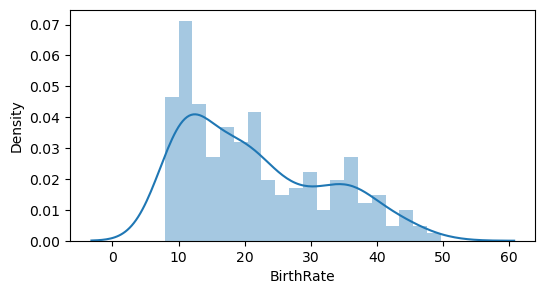

In [44]:
vis =sns.distplot(df['BirthRate'], bins=20, kde=True)
plt.show()